In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


import pickle

In [69]:
df = pd.read_csv('Crop_recommendation_expanded_12000.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.000000,42.000000,43.000000,20.879744,82.002744,6.502985,202.935536,rice
1,85.000000,58.000000,41.000000,21.770462,80.319644,7.038096,226.655537,rice
2,60.000000,55.000000,44.000000,23.004459,82.320763,7.840207,263.964248,rice
3,74.000000,35.000000,40.000000,26.491096,80.158363,6.980401,242.864034,rice
4,78.000000,42.000000,42.000000,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
11995,29.081242,143.836068,204.161847,22.527464,92.418260,5.812252,119.661851,apple
11996,39.795357,125.133063,200.951696,11.354356,80.226619,6.111717,70.799524,grapes
11997,91.561188,43.597301,14.758835,18.848649,65.758060,6.078618,94.641830,maize
11998,10.187775,71.092769,23.735652,21.181782,22.548060,5.602750,141.411174,kidneybeans


In [70]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice


In [71]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
11995,29.081242,143.836068,204.161847,22.527464,92.418260,5.812252,119.661851,apple
11996,39.795357,125.133063,200.951696,11.354356,80.226619,6.111717,70.799524,grapes
11997,91.561188,43.597301,14.758835,18.848649,65.758060,6.078618,94.641830,maize
11998,10.187775,71.092769,23.735652,21.181782,22.548060,5.602750,141.411174,kidneybeans
11999,13.210522,48.119593,20.676237,29.193546,84.904532,6.989806,53.451161,mungbean


In [72]:
df.shape

(12000, 8)

In [73]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [74]:
df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [75]:
df.dtypes

N              float64
P              float64
K              float64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [76]:
print(df['label'].head())
print(df['label'].dtype)

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object
object


In [77]:
X = df.drop('label', axis=1)
y = df['label']   


In [78]:
df.dtypes

N              float64
P              float64
K              float64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [79]:
x=df.iloc[:,:-1].values
x

array([[ 90.        ,  42.        ,  43.        , ...,  82.00274423,
          6.50298529, 202.9355362 ],
       [ 85.        ,  58.        ,  41.        , ...,  80.31964408,
          7.03809636, 226.6555374 ],
       [ 60.        ,  55.        ,  44.        , ...,  82.3207629 ,
          7.84020714, 263.9642476 ],
       ...,
       [ 91.56118773,  43.59730058,  14.75883497, ...,  65.75806031,
          6.07861813,  94.6418301 ],
       [ 10.18777506,  71.092769  ,  23.7356521 , ...,  22.54806019,
          5.60274951, 141.41117426],
       [ 13.21052185,  48.1195933 ,  20.67623655, ...,  84.90453158,
          6.9898063 ,  53.45116066]])

In [80]:
y=df.iloc[:,-1].values
y

array(['rice', 'rice', 'rice', ..., 'maize', 'kidneybeans', 'mungbean'],
      dtype=object)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.30,
    random_state=1
)

In [82]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
y_pred = rf_model.predict(X_test)


In [84]:
print("Random Forest Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")


Random Forest Accuracy: 100.0 %


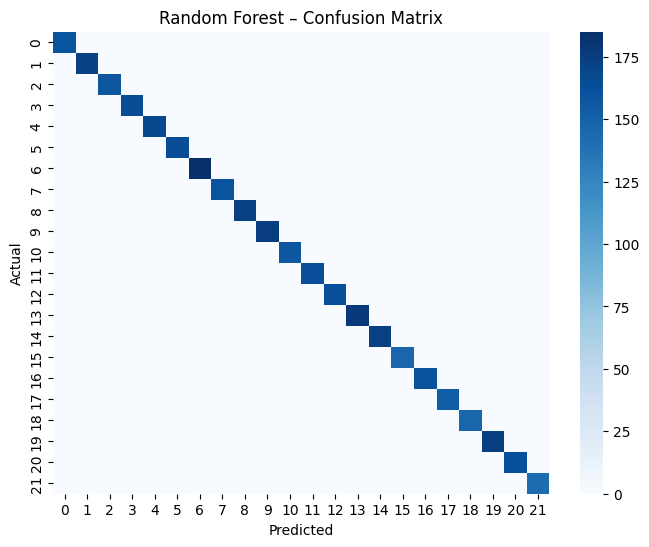

In [85]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest – Confusion Matrix")
plt.show()


In [86]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       159
      banana       1.00      1.00      1.00       172
   blackgram       1.00      1.00      1.00       158
    chickpea       1.00      1.00      1.00       165
     coconut       1.00      1.00      1.00       168
      coffee       1.00      1.00      1.00       165
      cotton       1.00      1.00      1.00       185
      grapes       1.00      1.00      1.00       160
        jute       1.00      1.00      1.00       174
 kidneybeans       1.00      1.00      1.00       175
      lentil       1.00      1.00      1.00       157
       maize       1.00      1.00      1.00       164
       mango       1.00      1.00      1.00       162
   mothbeans       1.00      1.00      1.00       178
    mungbean       1.00      1.00      1.00       174
   muskmelon       1.00      1.00      1.00       146
      orange       1.00      1.00      1.00       161
      papaya       1.00    

In [89]:
with open("crop_random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
